## 1. Install Dependencies

In [1]:
!pip install transformers datasets torch scikit-learn pandas openpyxl==3.1.0 seaborn matplotlib mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 104.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 82.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 39.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
import mlflow
import mlflow.pytorch
import os

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
USE_GENERATED_DATASET = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 3. Load & Explore the Data

In [5]:
if USE_GENERATED_DATASET:
    DATA_PATH = "/Users/iliakozhevnikov/Downloads/Mental_issues_dataset.xlsx"
    df = pd.read_excel(DATA_PATH)
else:
    DATA_PATH = "/kaggle/input/datasets/ilyakozhevnikov/combined-data/Combined Data.csv"
    df = pd.read_csv(
        DATA_PATH
    ).drop(
        columns=['Unnamed: 0']
    ).rename(
        columns={
            'statement': 'health_concerns',
            'status': 'class_txt'
        }
    )
    disease_to_class_num_sict = {}
    for class_num, disease in enumerate(df['class_txt'].unique()):
        disease_to_class_num_sict[disease] = class_num
    df['class_num'] = df['class_txt'].apply(lambda val: disease_to_class_num_sict[val])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (53043, 3)


,health_concerns,class_txt,class_num
0,oh my gosh,Anxiety,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,0
3,I've shifted my focus to something else but I'...,Anxiety,0
4,"I'm restless and restless, it's been a month n...",Anxiety,0


In [6]:
# df['length'] = df['health_concerns'].apply(lambda val: len(str(val)))
# df[df['length'] == 2]

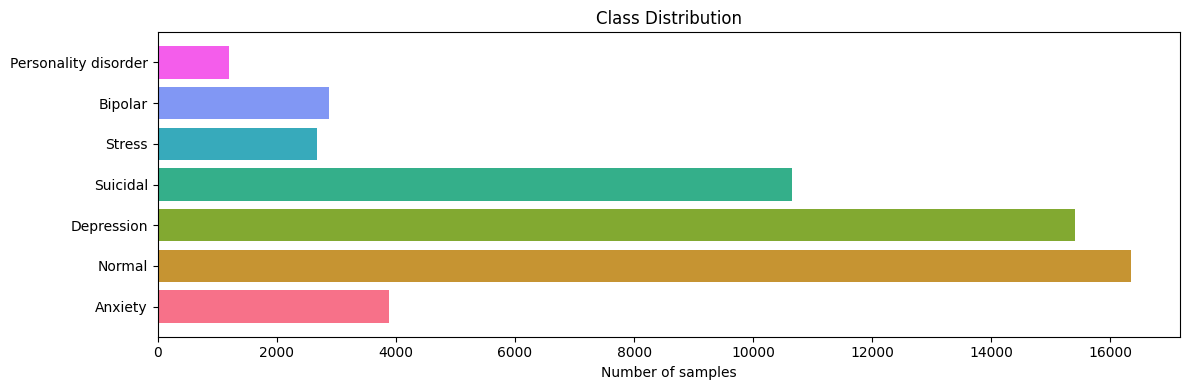


Class counts:
  [ 0] Anxiety                                          — 3888 samples
  [ 1] Normal                                           — 16351 samples
  [ 2] Depression                                       — 15404 samples
  [ 3] Suicidal                                         — 10653 samples
  [ 4] Stress                                           — 2669 samples
  [ 5] Bipolar                                          — 2877 samples
  [ 6] Personality disorder                             — 1201 samples


In [7]:
label_map = (
    df[['class_num', 'class_txt']]
    .drop_duplicates()
    .sort_values('class_num')
    .set_index('class_num')['class_txt']
    .to_dict()
)

counts = df['class_num'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
bars = plt.barh(
    [label_map[i] for i in counts.index],
    counts.values,
    color=sns.color_palette("husl", len(counts))
)
plt.xlabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

print("\nClass counts:")
for cls, cnt in counts.items():
    print(f"  [{cls:>2}] {label_map[cls]:<48} — {cnt} samples")

count    52410.000000
mean       113.738676
std        163.958816
min          2.000000
25%         16.000000
50%         63.000000
75%        149.000000
max       6300.000000
Name: text_len, dtype: float64


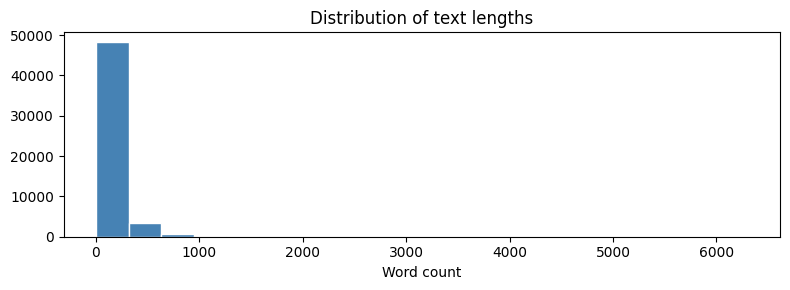

In [8]:
# Text length distribution
df['text_len'] = df['health_concerns'].str.split().str.len()
df = df[df['text_len'] > 1]
print(df['text_len'].describe())

plt.figure(figsize=(8, 3))
plt.hist(df['text_len'], bins=20, color='steelblue', edgecolor='white')
plt.xlabel("Word count")
plt.title("Distribution of text lengths")
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

In [9]:
NUM_LABELS = df['class_num'].nunique()
print(f"Number of classes: {NUM_LABELS}")

X = df['health_concerns'].tolist()
y = df['class_num'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y          # preserve class balance
)

print(f"Train samples : {len(X_train)}")
print(f"Val   samples : {len(X_val)}")

Number of classes: 7
Train samples : 41928
Val   samples : 10482


## 5. Tokenizer & PyTorch Dataset

In [10]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 256        # Most texts fit well under 256 tokens

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'token_type_ids': self.encodings['token_type_ids'][idx],
            'labels':         self.labels[idx]
        }


train_dataset = MentalHealthDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = MentalHealthDataset(X_val,   y_val,   tokenizer, MAX_LEN)

BATCH_SIZE = 8   # Lower if GPU memory is tight; increase for faster training

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("Tokenisation complete.")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenisation complete.
Train batches: 5241  |  Val batches: 1311


## 6. Model Setup

In [11]:
MODEL_NAME = "bert-base-uncased"

def build_model_and_optimizer(num_labels, lr, dropout):
    """Instantiate a fresh BERT model + AdamW optimizer for a single HPO trial."""
    mdl = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout,
    )
    mdl = mdl.to(DEVICE)
    opt = AdamW(mdl.parameters(), lr=lr, weight_decay=0.01)
    return mdl, opt

# ── Narrow hyperparameter grid (keeps total wall-time manageable) ─────────────
# 2 learning-rates × 2 dropouts = 4 runs; each runs EPOCHS_HPO epochs.
# Increase EPOCHS_HPO / extend the lists only if you have GPU time to spare.
PARAM_GRID = {
    "lr":      [2e-5, 3e-5],
    "dropout": [0.1, 0.3],
}
EPOCHS_HPO   = 3     # short run per trial — enough to rank configs
BATCH_SIZE   = 8

print("Hyperparameter grid:")
for k, v in PARAM_GRID.items():
    print(f"  {k}: {v}")
print(f"Total trials : {len(PARAM_GRID['lr']) * len(PARAM_GRID['dropout'])}")
print(f"Epochs/trial : {EPOCHS_HPO}")


Hyperparameter grid:
  lr: [2e-05, 3e-05]
  dropout: [0.1, 0.3]
Total trials : 4
Epochs/trial : 3


## 7. Training Loop

In [ ]:
# helper kept from original notebook
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            token_type_ids = batch['token_type_ids'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels,
            )
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_labels, all_preds


# ── MLflow experiment ─────────────────────────────────────────────────────────
EXPERIMENT_NAME = "bert-mental-health-hpo"
mlflow.set_experiment(EXPERIMENT_NAME)

best_val_f1        = 0.0
best_model_path    = "best_bert_mental_health.pt"
best_run_id        = None
best_params        = {}

import itertools
grid = list(itertools.product(PARAM_GRID["lr"], PARAM_GRID["dropout"]))

for lr, dropout in grid:
    run_name = f"lr={lr}_dropout={dropout}"
    print(f"\n{'='*60}")
    print(f"Starting trial: {run_name}")
    print(f"{'='*60}")

    with mlflow.start_run(run_name=run_name) as run:

        # ── Log hyperparameters ───────────────────────────────────────────────
        mlflow.log_params({
            "model_name":    MODEL_NAME,
            "learning_rate": lr,
            "dropout":       dropout,
            "epochs":        EPOCHS_HPO,
            "batch_size":    BATCH_SIZE,
            "max_len":       MAX_LEN,
            "warmup_steps":  0,
            "weight_decay":  0.01,
            "seed":          SEED,
        })

        # ── Build fresh model + scheduler for this trial ──────────────────────
        model, optimizer = build_model_and_optimizer(NUM_LABELS, lr, dropout)
        total_steps = len(train_loader) * EPOCHS_HPO
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=0,
            num_training_steps=total_steps,
        )

        history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
        trial_best_f1 = 0.0

        for epoch in range(1, EPOCHS_HPO + 1):
            # Training
            model.train()
            running_loss = 0.0
            for batch in train_loader:
                input_ids      = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                token_type_ids = batch['token_type_ids'].to(DEVICE)
                labels         = batch['labels'].to(DEVICE)
                optimizer.zero_grad()
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids,
                    labels=labels,
                )
                outputs.loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                running_loss += outputs.loss.item()

            train_loss = running_loss / len(train_loader)
            val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_f1"].append(val_f1)

            # ── Log per-epoch metrics to MLflow ──────────────────────────────
            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_loss":   val_loss,
                "val_acc":    val_acc,
                "val_f1":     val_f1,
            }, step=epoch)

            print(
                f"  Epoch {epoch}/{EPOCHS_HPO}  "
                f"train_loss={train_loss:.4f}  "
                f"val_loss={val_loss:.4f}  "
                f"val_acc={val_acc:.4f}  "
                f"val_f1={val_f1:.4f}"
            )

            if val_f1 > trial_best_f1:
                trial_best_f1 = val_f1

        # ── Log summary metrics for easy comparison in MLflow UI ─────────────
        mlflow.log_metrics({
            "best_val_f1":  trial_best_f1,
            "final_val_acc": history["val_acc"][-1],
        })

        # ── Log training-curves figure as an MLflow artifact ─────────────────
        epochs_range = range(1, EPOCHS_HPO + 1)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train")
        axes[0].plot(epochs_range, history["val_loss"],   marker="o", label="Val")
        axes[0].set_title("Loss"); axes[0].legend()
        axes[1].plot(epochs_range, history["val_acc"],  color="green",  marker="o")
        axes[1].set_title("Val Accuracy")
        axes[2].plot(epochs_range, history["val_f1"],   color="orange", marker="o")
        axes[2].set_title("Val F1")
        plt.suptitle(f"Training curves — {run_name}", fontsize=11)
        plt.tight_layout()
        curves_path = f"training_curves_{run_name.replace('=','').replace('.','')}.png"
        plt.savefig(curves_path)
        plt.show()
        mlflow.log_artifact(curves_path)
        os.remove(curves_path)

        # ── Persist best overall model ────────────────────────────────────────
        if trial_best_f1 > best_val_f1:
            best_val_f1  = trial_best_f1
            best_run_id  = run.info.run_id
            best_params  = {"lr": lr, "dropout": dropout}
            torch.save(model.state_dict(), best_model_path)
            # Also log the checkpoint as an MLflow artifact on this run
            mlflow.log_artifact(best_model_path)
            print(f"  ✓ New overall best  val_f1={best_val_f1:.4f}  (run: {run.info.run_id[:8]})")

print(f"\n{'='*60}")
print(f"HPO complete.")
print(f"Best val F1 : {best_val_f1:.4f}")
print(f"Best params : {best_params}")
print(f"Best run ID : {best_run_id}")
print(f"View results: mlflow ui  (in the directory where you ran this notebook)")
print(f"{'='*60}")

# Expose `model` pointing to the best checkpoint for the cells below
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))


2026/05/30 14:29:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/30 14:29:10 INFO mlflow.store.db.utils: Updating database tables
2026/05/30 14:29:12 INFO mlflow.tracking.fluent: Experiment with name 'bert-mental-health-hpo' does not exist. Creating a new experiment.



Starting trial: lr=2e-05_dropout=0.1


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 8. Training Curves

In [ ]:
# Training curves for the *last* HPO trial are already shown above per-run.
# This cell re-plots the best run's history if you want a standalone figure.
epochs_range = range(1, EPOCHS_HPO + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], color='green', marker='o')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], color='orange', marker='o')
axes[2].set_title('Validation Weighted F1'); axes[2].set_xlabel('Epoch')

plt.suptitle(f'BERT HPO — Best trial: {best_params}', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Best hyperparameters: {best_params}")
print(f"Best val F1         : {best_val_f1:.4f}")


## 9. Evaluate Best Model

In [ ]:
# The HPO sweep already loaded the best checkpoint into `model`.
# This cell re-evaluates it and prints the full classification report.
val_loss, val_acc, val_f1, true_labels, pred_labels = evaluate(model, val_loader)

print(f"Best params         : {best_params}")
print(f"Best MLflow run ID  : {best_run_id}")
print()
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Validation F1 (w)   : {val_f1:.4f}")
print()
print(classification_report(
    true_labels, pred_labels,
    target_names=[label_map[i] for i in range(NUM_LABELS)]
))

# Log the classification report as a text artifact on the best run
report_txt = classification_report(
    true_labels, pred_labels,
    target_names=[label_map[i] for i in range(NUM_LABELS)]
)
report_path = "classification_report.txt"
with open(report_path, "w") as fp:
    fp.write(f"Best params: {best_params}\n\n")
    fp.write(report_txt)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(report_path)

os.remove(report_path)
print("\nClassification report logged to MLflow.")


In [ ]:
# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
short_labels = [
    label_map[i].replace('Disorder', 'Dis.').replace('Generalized Anxiety', 'GAD')
    for i in range(NUM_LABELS)
]

plt.figure(figsize=(11, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=short_labels,
    yticklabels=short_labels,
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Validation Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Log the confusion-matrix figure to the best MLflow run
cm_fig_path = "confusion_matrix.png"
plt.savefig(cm_fig_path, bbox_inches='tight')

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(cm_fig_path)

os.remove(cm_fig_path)
print("Confusion matrix logged to MLflow.")


## 10. Inference on New Patient Text

In [ ]:
def predict(text: str, model=model, tokenizer=tokenizer,
            max_len=MAX_LEN, device=DEVICE, label_map=label_map):
    """Return predicted class_num, diagnosis label, and class probabilities."""
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids      = encoding['input_ids'].to(device),
            attention_mask = encoding['attention_mask'].to(device),
            token_type_ids = encoding['token_type_ids'].to(device)
        )
    probs      = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    class_num  = int(probs.argmax())
    diagnosis  = label_map[class_num]
    confidence = probs[class_num]
    return class_num, diagnosis, confidence, probs


# ── Demo ──
sample_texts = [
    # Likely anxiety
    "I can't stop worrying about everything. Even small things feel catastrophic and I'm always waiting for something bad to happen.",
    # Likely depression
    "I've lost all interest in things I used to enjoy. Getting out of bed feels impossible and I feel completely empty.",
    # Likely PTSD
    "I keep having nightmares about the accident. A car backfiring sends me into a panic and I avoid driving completely.",
]

for text in sample_texts:
    cls, diag, conf, probs = predict(text)
    print(f"Text     : {text[:90]}...")
    print(f"Diagnosis: [{cls}] {diag}  (confidence: {conf:.1%})")
    print()

In [ ]:
# Visual probability bar chart for a single prediction
text_to_inspect = sample_texts[0]
cls, diag, conf, probs = predict(text_to_inspect)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if i == cls else '#3498db' for i in range(NUM_LABELS)]
ax.barh([label_map[i] for i in range(NUM_LABELS)], probs, color=colors)
ax.set_xlabel('Probability')
ax.set_title(f'Prediction: "{text_to_inspect[:60]}..."\nPredicted → {diag}')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 11. Save Full Model & Tokenizer

In [ ]:
SAVE_DIR = "bert_mental_health_model"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save the label map for downstream use
import json
with open(f"{SAVE_DIR}/label_map.json", "w") as f:
    json.dump({str(k): v for k, v in label_map.items()}, f, indent=2)

print(f"Model, tokenizer, and label map saved to './{SAVE_DIR}/'")

## 12. Load & Use Saved Model (standalone example)

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
import json, torch

SAVE_DIR = "bert_mental_health_model"

loaded_tokenizer = BertTokenizer.from_pretrained(SAVE_DIR)
loaded_model     = BertForSequenceClassification.from_pretrained(SAVE_DIR)
loaded_model     = loaded_model.to(DEVICE)

with open(f"{SAVE_DIR}/label_map.json") as f:
    loaded_label_map = {int(k): v for k, v in json.load(f).items()}

# Test
test_text = "I feel paralysed by sadness. Nothing excites me anymore and I sleep 14 hours a day."
cls, diag, conf, _ = predict(
    test_text,
    model=loaded_model,
    tokenizer=loaded_tokenizer,
    label_map=loaded_label_map
)
print(f"Text      : {test_text}")
print(f"Diagnosis : [{cls}] {diag}  ({conf:.1%} confidence)")

## 13. MLflow Experiment Summary

In [ ]:
# Display all runs in this experiment as a DataFrame for easy comparison
import mlflow

runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.best_val_f1 DESC"],
)

cols = [
    "run_id",
    "params.learning_rate",
    "params.dropout",
    "params.epochs",
    "metrics.best_val_f1",
    "metrics.final_val_acc",
]
# Keep only columns that exist (MLflow prefixes differ by version)
cols = [c for c in cols if c in runs_df.columns]
print(runs_df[cols].to_string(index=False))

print("\nTo open the MLflow UI, run in a terminal:")
print("  mlflow ui")
print("Then navigate to http://localhost:5000")
